In [2489]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
from collections import Counter
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation
import random
np.random.seed(42)
random.seed(42)

In [2429]:
data_df = pd.read_csv('C:\\Users\\Shankar\\Desktop\\customer data set hugging face\\customer_support_tickets.csv')
data_df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [2430]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [2431]:
for column in data_df.columns:
    print(f"{column}: {data_df[column].isnull().sum()} null values")

Ticket ID: 0 null values
Customer Name: 0 null values
Customer Email: 0 null values
Customer Age: 0 null values
Customer Gender: 0 null values
Product Purchased: 0 null values
Date of Purchase: 0 null values
Ticket Type: 0 null values
Ticket Subject: 0 null values
Ticket Description: 0 null values
Ticket Status: 0 null values
Resolution: 5700 null values
Ticket Priority: 0 null values
Ticket Channel: 0 null values
First Response Time: 2819 null values
Time to Resolution: 5700 null values
Customer Satisfaction Rating: 5700 null values


## Univariant Analysis

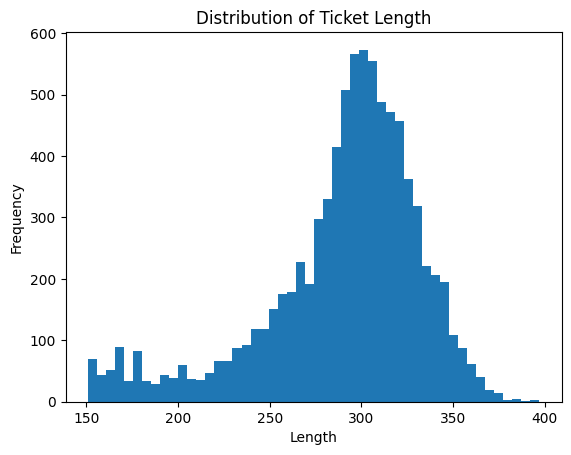

In [2432]:
data_df['text_length'] = data_df['Ticket Description'].astype(str).apply(len)

plt.hist(data_df['text_length'], bins=50)
plt.title("Distribution of Ticket Length")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

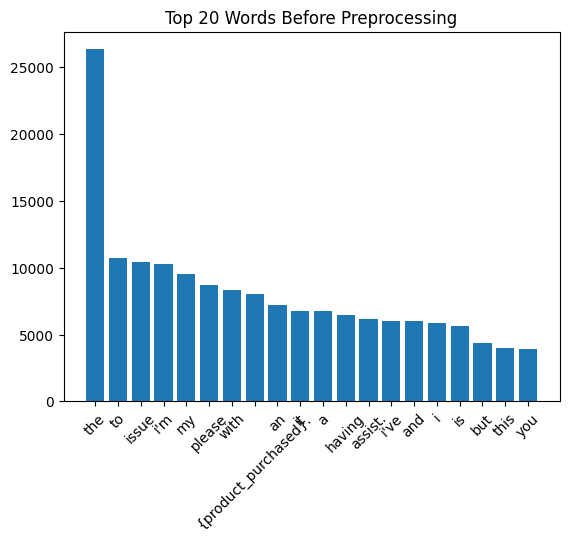

In [2433]:
text_data = data_df['Ticket Description'].astype(str)

all_words = " ".join(text_data).lower().split()
common_words = Counter(all_words).most_common(20)

words, counts = zip(*common_words)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Words Before Preprocessing")
plt.show()

In [2434]:
unique_words = set(all_words)
print("Vocabulary size:", len(unique_words))

Vocabulary size: 13826


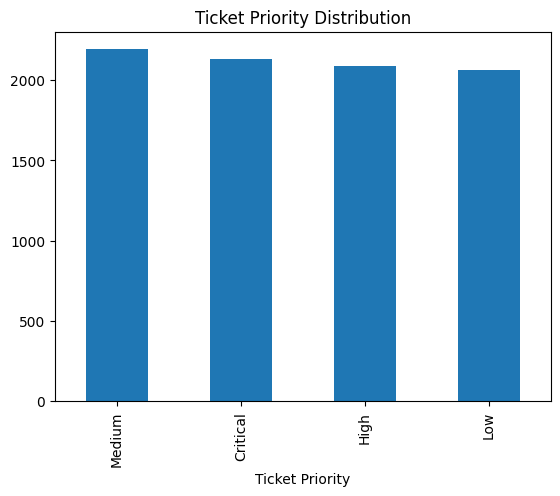

In [2435]:
data_df['Ticket Priority'].value_counts().plot(kind='bar')
plt.title("Ticket Priority Distribution")
plt.show()

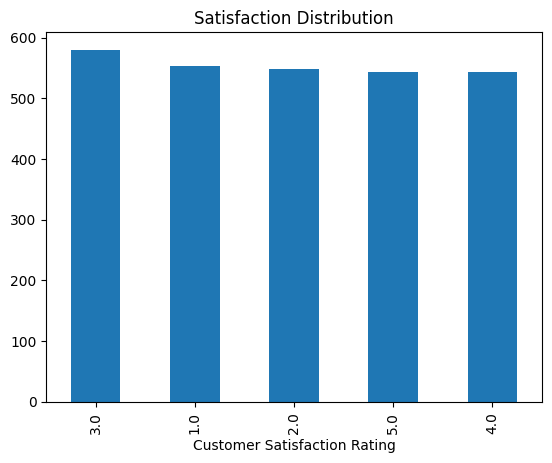

In [2436]:
data_df['Customer Satisfaction Rating'].value_counts().plot(kind='bar')
plt.title("Satisfaction Distribution")
plt.show()

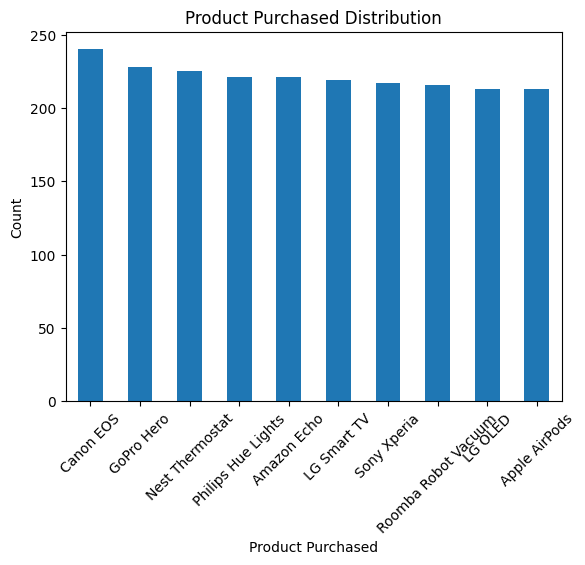

In [2437]:
data_df['Product Purchased'].value_counts().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Product Purchased Distribution")
plt.xlabel("Product Purchased")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

Text(0, 0.5, 'Count')

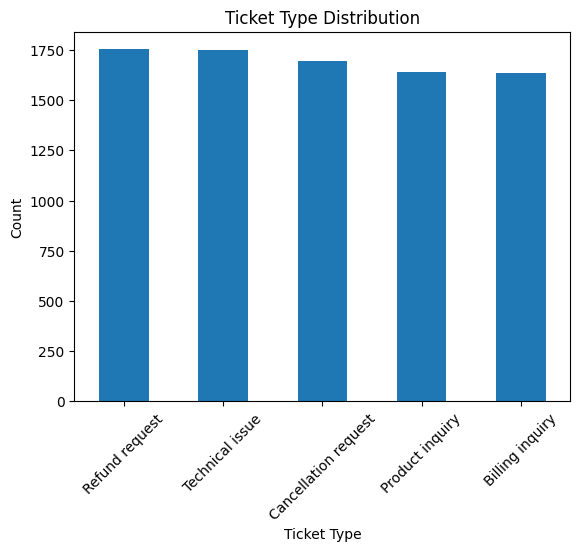

In [2438]:
data_df['Ticket Type'].value_counts().plot(kind='bar')
plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.xticks(rotation=45)
plt.ylabel("Count")

In [2439]:
data_df['Ticket Type'].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

These are like the ground truth values. Meaning we can use these ticket type to evalute the clusters

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


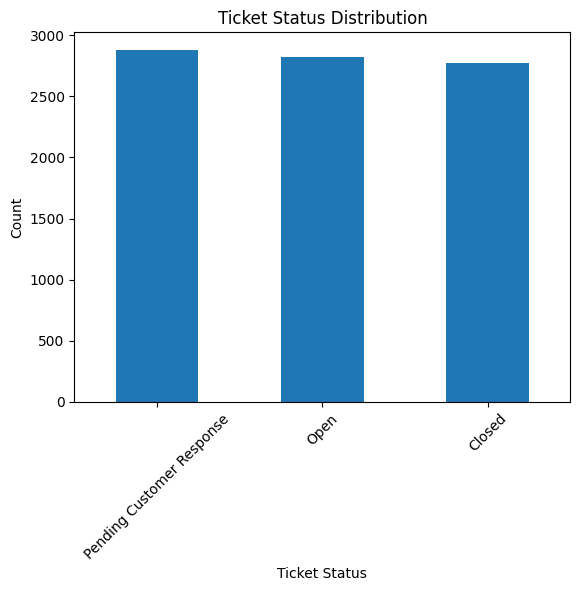

In [2440]:
print(data_df['Ticket Type'].value_counts())
data_df['Ticket Status'].value_counts().plot(kind='bar')
plt.title("Ticket Status Distribution") 
plt.xlabel("Ticket Status")
plt.xticks(rotation=45) 
plt.ylabel("Count")
plt.show()  

In [2441]:
data_df['Customer Age'].agg(['mean', 'max', 'min'])

mean    44.026804
max     70.000000
min     18.000000
Name: Customer Age, dtype: float64

In [2442]:
data_df['Date of Purchase'].agg(['max', 'min'])

max    2021-12-30
min    2020-01-01
Name: Date of Purchase, dtype: str

Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64


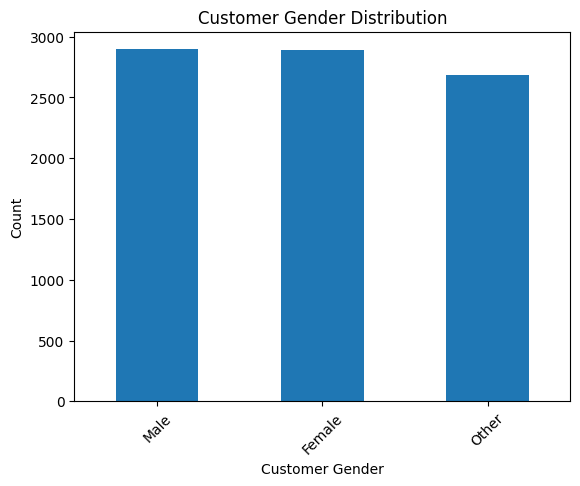

In [2443]:
print(data_df['Customer Gender'].value_counts())
data_df['Customer Gender'].value_counts().plot(kind='bar')
plt.title("Customer Gender Distribution")
plt.xlabel("Customer Gender")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

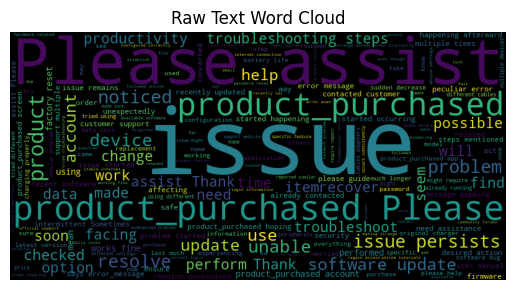

In [2444]:
wordcloud = WordCloud(width=800, height=400).generate(" ".join(text_data))

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Raw Text Word Cloud")
plt.show()

Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64


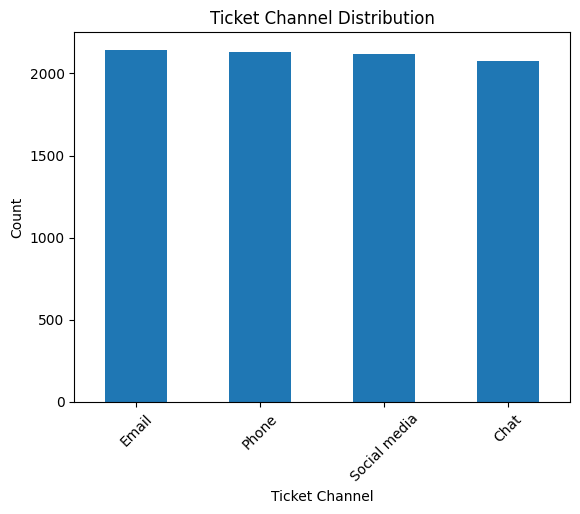

In [2445]:
print(data_df['Ticket Channel'].value_counts())
data_df['Ticket Channel'].value_counts().plot(kind='bar')
plt.title("Ticket Channel Distribution")
plt.xlabel("Ticket Channel")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

In [2446]:
for i in range(len(data_df['Ticket Description'])):
    text = data_df['Ticket Description'][i]
    exists = bool(re.search(r'\{.*?\}', text))
    if exists:
        found = re.findall(r'\{.*?\}', text)
        if found != "{Product_purchased}":
            print(f"Found patterns in ticket {i}: {found}")

Found patterns in ticket 0: ['{product_purchased}']
Found patterns in ticket 1: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 2: ['{product_purchased}', '{product_purchased}', '{product_purchased}']
Found patterns in ticket 3: ['{product_purchased}']
Found patterns in ticket 4: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 5: ['{product_purchased}', '{product_purchased}', "{product_purch I've checked for any available software updates for my {product_purchased}"]
Found patterns in ticket 6: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 7: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 8: ['{product_purchased}', '{product_purchased}', '{product_purchased}']
Found patterns in ticket 9: ['{product_purchased}']
Found patterns in ticket 10: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 11: ['{product_purchased}']
Found patterns in ticket 12: ['{product_purchased}'

We will have to remove these text messages so that the clusters come out to be clean

## Bivariate Analysis

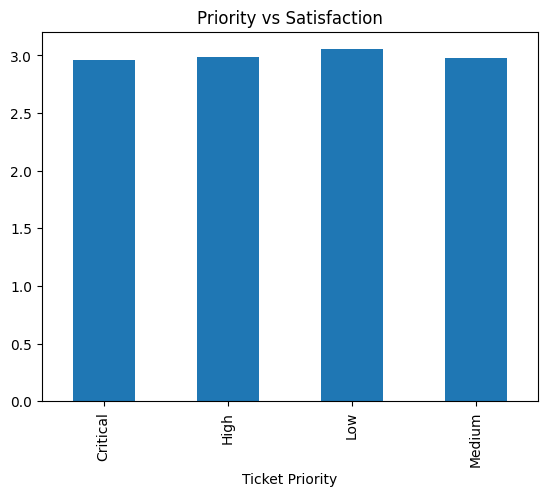

In [2447]:
data_df.groupby('Ticket Priority')['Customer Satisfaction Rating'].mean().plot(kind='bar')
plt.title("Priority vs Satisfaction")
plt.show()

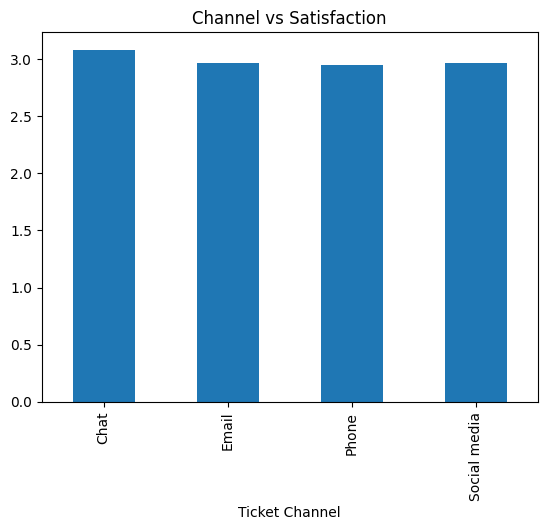

In [2448]:
data_df.groupby('Ticket Channel')['Customer Satisfaction Rating'].mean().plot(kind='bar')
plt.title("Channel vs Satisfaction")
plt.show()

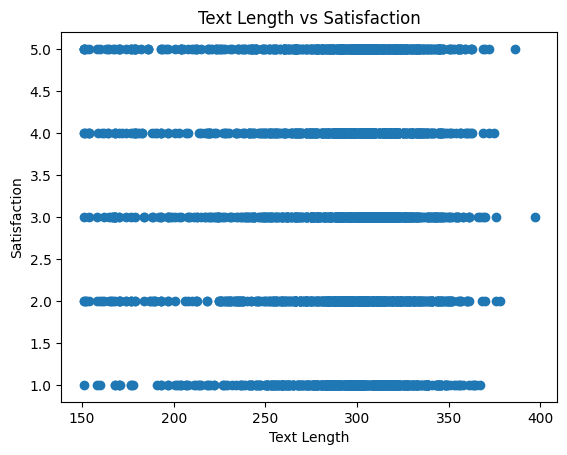

In [2449]:
plt.scatter(data_df['text_length'], data_df['Customer Satisfaction Rating'])
plt.xlabel("Text Length")
plt.ylabel("Satisfaction")
plt.title("Text Length vs Satisfaction")
plt.show()

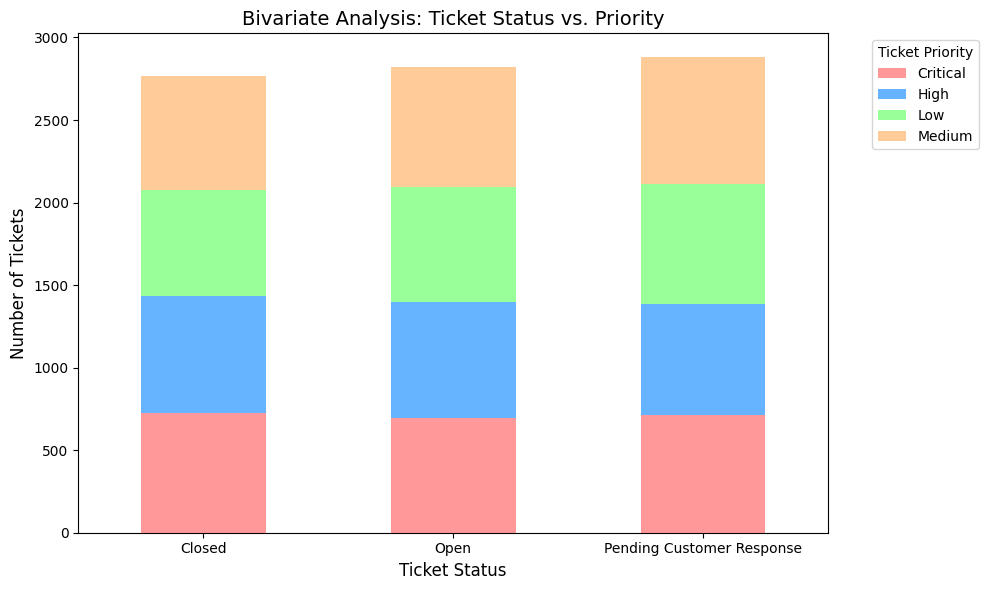

In [2450]:
status_priority_map = pd.crosstab(data_df['Ticket Status'], data_df['Ticket Priority'])
status_priority_map.plot(kind='bar', 
                         stacked=True, 
                         figsize=(10, 6), 
                         color=['#ff9999','#66b3ff','#99ff99','#ffcc99'])

plt.title("Bivariate Analysis: Ticket Status vs. Priority", fontsize=14)
plt.xlabel("Ticket Status", fontsize=12)
plt.ylabel("Number of Tickets", fontsize=12)
plt.legend(title="Ticket Priority", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

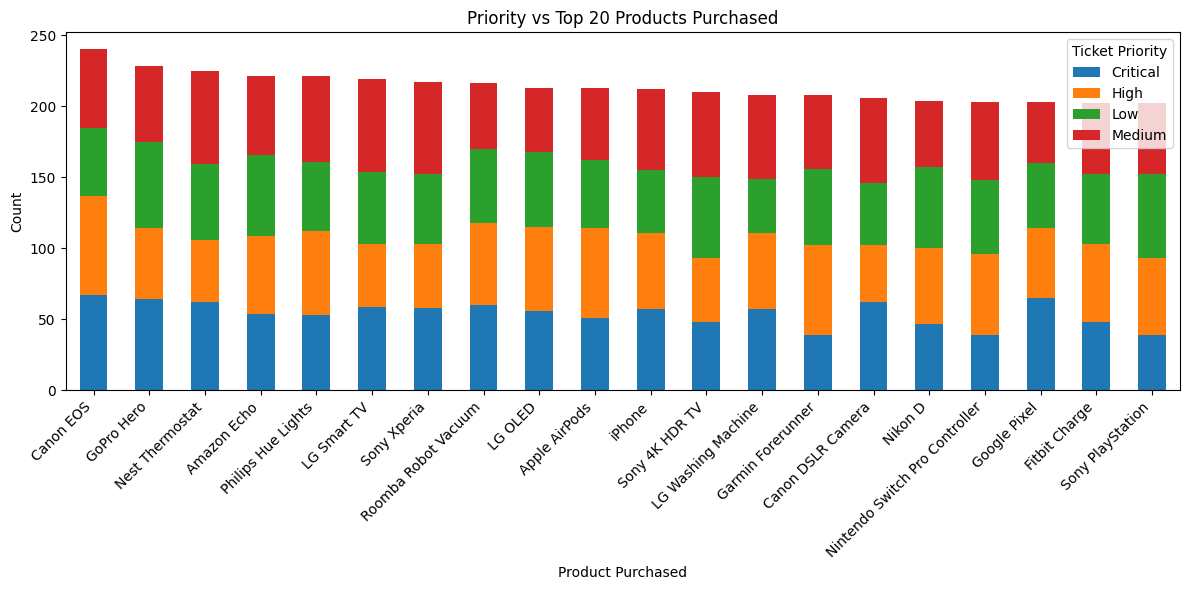

In [2451]:
top_20_products = data_df['Product Purchased'].value_counts().nlargest(20).index
filtered_df = data_df[data_df['Product Purchased'].isin(top_20_products)]
plot_data = filtered_df.groupby(['Product Purchased', 'Ticket Priority']).size().unstack()
plot_data['Total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values('Total', ascending=False).drop(columns='Total')

plot_data.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Priority vs Top 20 Products Purchased")
plt.xlabel("Product Purchased")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Ticket Priority')
plt.tight_layout()
plt.show()

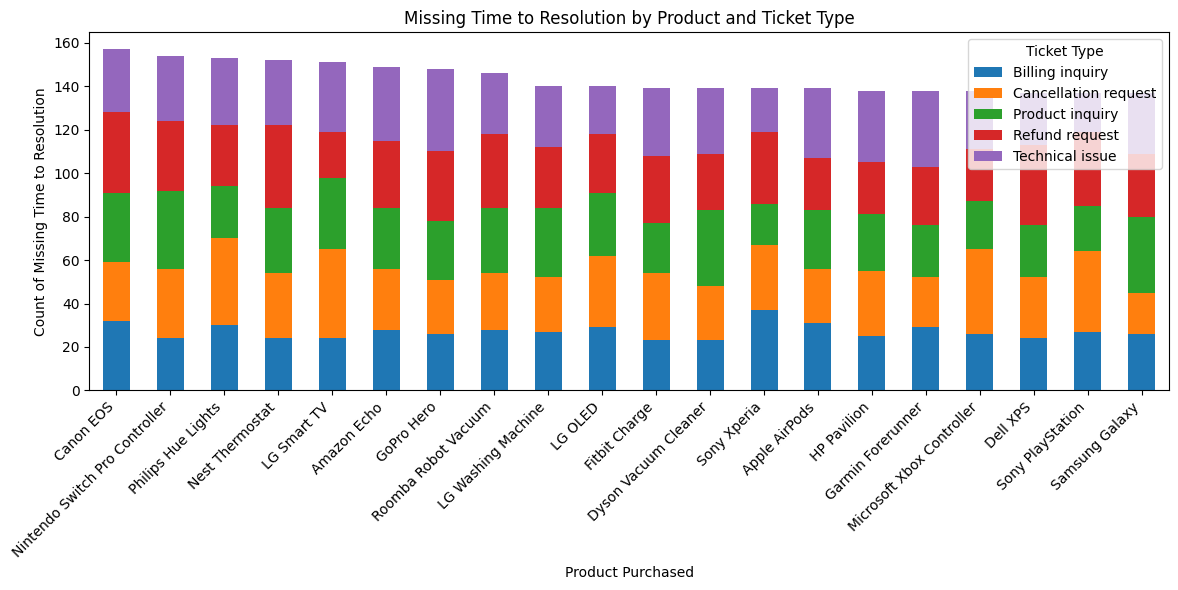

In [2452]:
missingdata = data_df['Time to Resolution'].isnull()
missingplotdata_df = data_df[missingdata].groupby(['Product Purchased', 'Ticket Type']).size().unstack()
missingplotdata_df = missingplotdata_df.assign(Total=missingplotdata_df.sum(axis=1)).sort_values(by='Total', ascending=False).drop(columns='Total').head(20)
missingplotdata_df.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Missing Time to Resolution by Product and Ticket Type")
plt.xlabel("Product Purchased")
plt.ylabel("Count of Missing Time to Resolution")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

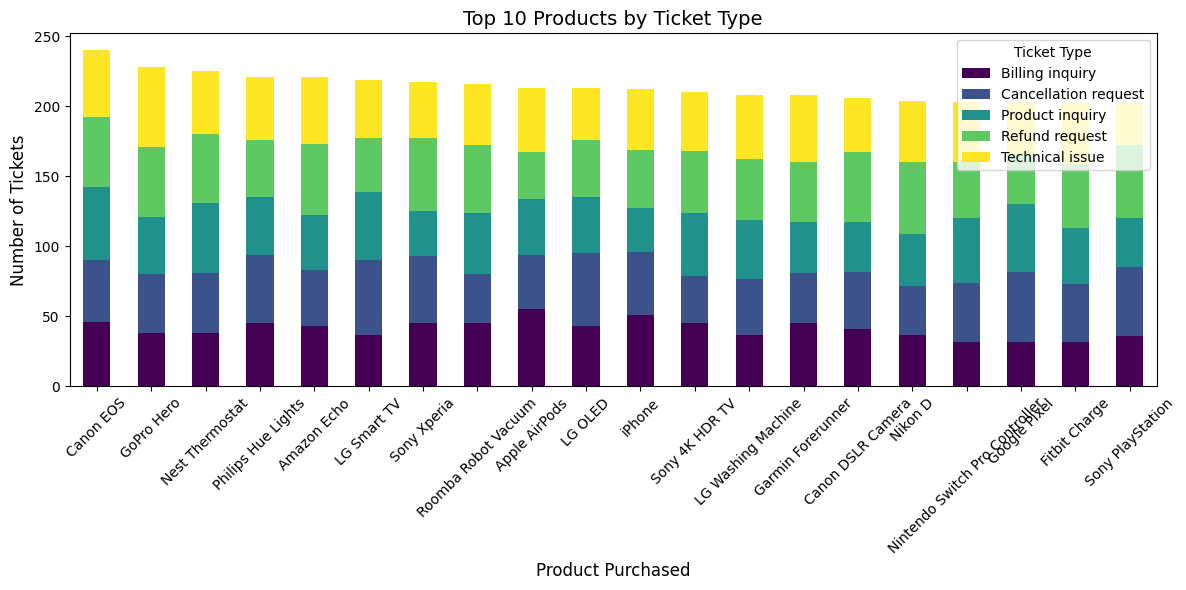

In [2453]:
plot_data = data_df.groupby(['Product Purchased', 'Ticket Type']).size().unstack()
plot_data = plot_data.assign(Total=plot_data.sum(axis=1)).sort_values(by='Total', ascending=False).drop(columns='Total').head(20)
plot_data.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title("Top 10 Products by Ticket Type", fontsize=14)
plt.xlabel("Product Purchased", fontsize=12)
plt.ylabel("Number of Tickets", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Ticket Type")
plt.tight_layout()

## Multivariant Analysis

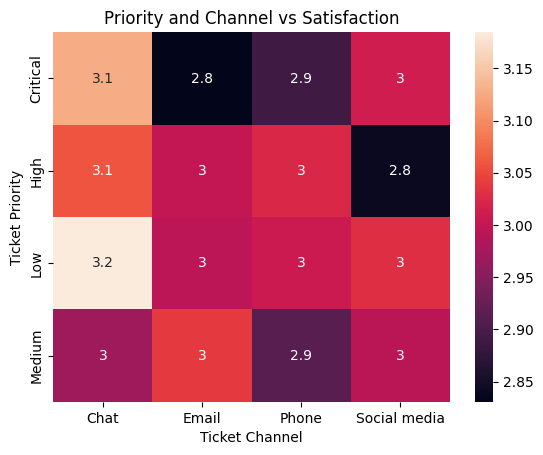

In [2454]:
pivot = data_df.pivot_table(values='Customer Satisfaction Rating',index='Ticket Priority',columns='Ticket Channel',aggfunc='mean')
sns.heatmap(pivot, annot=True)
plt.title("Priority and Channel vs Satisfaction")
plt.show()

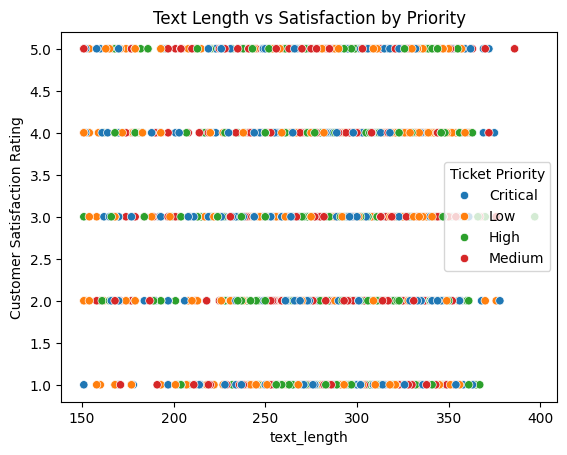

In [2455]:
sns.scatterplot(data=data_df,x='text_length',y='Customer Satisfaction Rating',hue='Ticket Priority')
plt.title("Text Length vs Satisfaction by Priority")
plt.show()

## Preprocessing

In [2456]:
# for i in range(len(data_df)):
#     product_purchased = data_df.iloc[i]['Product Purchased']
#     text = data_df.iloc[i]['Ticket Description']
#     updated_text = text.replace('{product_purchased}', product_purchased)
#     data_df.at[data_df.index[i], 'Ticket Description'] = updated_text


# data_df.head()

In [2457]:
data_df['text'] = data_df['Ticket Subject'].fillna('') + " " + data_df['Ticket Description'].fillna('')

In [2458]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}', '', text)
    text = re.sub(r'http\S+', '', text) # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\b[a-zA-Z]{1,2}\b', '', text)  # remove very short words
    return text

data_df['clean_text'] = data_df['text'].apply(clean_text)
data_df['clean_text'].head()

0    product setup  having  issue with the  please ...
1    peripheral compatibility  having  issue with t...
2    network problem  facing  problem with   the   ...
3    account access  having  issue with the  please...
4    data loss  having  issue with the  please assi...
Name: clean_text, dtype: str

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# removing the words from the word cloud which i did above
#custom_words = {'please', 'help', 'issue', 'product', 'customer'}


###overfitting
# custom_words = {
#     'please', 'help', 'assist', 'support', 'thanks', 'thank','would',
#     'could', 'im', 'ive', 'issue','problem','hoping','contacted','tried',
#     'trying', 'check', 'checked', 'perform', 'performed','need', 'want',
#     'using', 'use', 'used', 'user', 'us','time','happening','everything',
#     'something', 'anything','customer', 'product', 'purchased', 'request',
#     'refund', 'payment', 'delivery', 'item','also', 'already', 'multiple',
#     'recently','didnt', 'did','get', 'getting', 'make', 'made','data','step',
#     'noticed','work','fine','available','facing','might','option','say', 'find',
#     'doe', 'like', 'seems', 'guide', 'message','sure', 'soon', 'mean', 'different',
#     'productivity', 'specific', 'troubleshooting', 'troubleshoot',
#     'possible', 'action', 'setting', 'setup', 'installation',
#     'recommendation', 'assistance','way','sometimes','act','related','havent',
#     'information', 'try','desired','new','recent','afterward','affecting','cancellation','contact', 'remains', 'occuring',
#     'account', 'device', 'hardware', 'network',
#     'software', 'compatibility', 'working', 'properly', 'configuration',
#     'none', 'update', 'updated', 'started',
#     'order', 'purchase', 'name', 'email',
#     'access', 'display', 'know', 'loss',
#     'fix', 'price', 'one', 'add', 'note', 'may', 'dont', 'store'

# }

####too harsh
# custom_words = {
#     'please', 'help', 'assist', 'support', 'thanks', 'thank','would',
#     'could', 'im', 'ive', 'issue','problem','hoping','contacted','tried',
#     'trying', 'check', 'checked', 'perform', 'performed','need', 'want',
#     'using', 'use', 'used', 'user', 'us','time','happening','everything',
#     'something', 'anything','customer', 'product', 'purchased', 'request',
#     'refund', 'payment', 'delivery', 'item','also', 'already', 'multiple',
#     'recently','didnt', 'did','get', 'getting', 'make', 'made','data','step',
#     'noticed','work','fine','available','facing','might','find','does',
#     'seems', 'guide','sure','soon','different','productivity','specific',
#     'possible','setup','installation','recommendation','assistance','way',
#     'sometimes','act','related','havent','information','try','desired','new',
#     'recent','afterward','affecting','cancellation','contact','remains','occuring',
#     'working','properly','none','order','purchase','name','email',
#     'know','price','one','add','note','may','dont','store'
# }

####not very proper clusters
custom_words = {
    'please', 'help', 'assist', 'support', 'thanks', 'thank','soon','mentioned',
    'im', 'ive', 'us','would', 'could', 'need', 'want', 'trying',
    'tried','check', 'checked', 'make', 'made', 'get', 'getting','also',
    'use', 'using', 'used','thing', 'something', 'anything', 'everything',
    'way', 'time','customer', 'product', 'purchased', 'order', 'purchase',
    'refund', 'payment', 'delivery', 'item','issue', 'problem', 'request',
    'work', 'working', 'fine', 'available', 'recent', 'recently','facing', 'doe',
    'noticed', 'happening', 'started', 'happen','different', 'steps', 'did',
    'regards','already', 'multiple','last','times','followed', 'reviewed',
    'specific', 'possible', 'related','new', 'old','find', 'try', 'trying', 'say', 'mean',
    'name', 'email', 'price', 'one', 'add','note', 'may', 'dont', 'know','sure',
    'changes', 'performed', 'properly','original','like', 'similar','reported','doesnt',
    'sometimes', 'acts', 'works', 'ensure', 'desired', 'action', 'remains', 'life', 'seems',
    'might', 'guide', 'much', 'others',
    'heavily', 'daily', 'task',
    'affecting', 'assistance',
    'hoping',
    'persists','didnt',
    'option', 'perform', 'recommendation', 'information', 'official'
}
# 'customer', 'product',
# 'refund', 'payment', 'delivery',
# 'order', 'purchase', 'item'
# 'refund', 'payment', 'delivery', 'order', 'purchase', 'product'
# 'issue', 'problem', 'request'
#    'hoping', 'contacted','perform', 'performed','step','unresolved', 'persists',
#   'information'

#'hardware', 'software', 'account'
# remmvoing the workds 'software', 'device', 'issue' as they are very common and not useful for clustering

custom_words_lemma = set([lemmatizer.lemmatize(w) for w in custom_words])

def preprocess(text):
    tokens = word_tokenize(text)
    
    processed_tokens = []
    
    for word in tokens:
        lemma = lemmatizer.lemmatize(word)
        
        if lemma not in stop_words and lemma not in custom_words_lemma and len(lemma) > 2:
            processed_tokens.append(lemma)
    
    return " ".join(processed_tokens)

data_df['processed_text'] = data_df['clean_text'].apply(preprocess)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shankar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shankar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Shankar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2460]:
data_df[['text', 'processed_text']].head(5)

,text,processed_text
0,Product setup I'm having an issue with the {pr...,setup billing zip code appreciate requested we...
1,Peripheral compatibility I'm having an issue w...,peripheral compatibility existing intermittent...
2,Network problem I'm facing a problem with my {...,network turning yesterday respond really charg...
3,Account access I'm having an issue with the {p...,account access youre interested love see feedb...
4,Data loss I'm having an issue with the {produc...,data loss seller responsible damage arising ba...


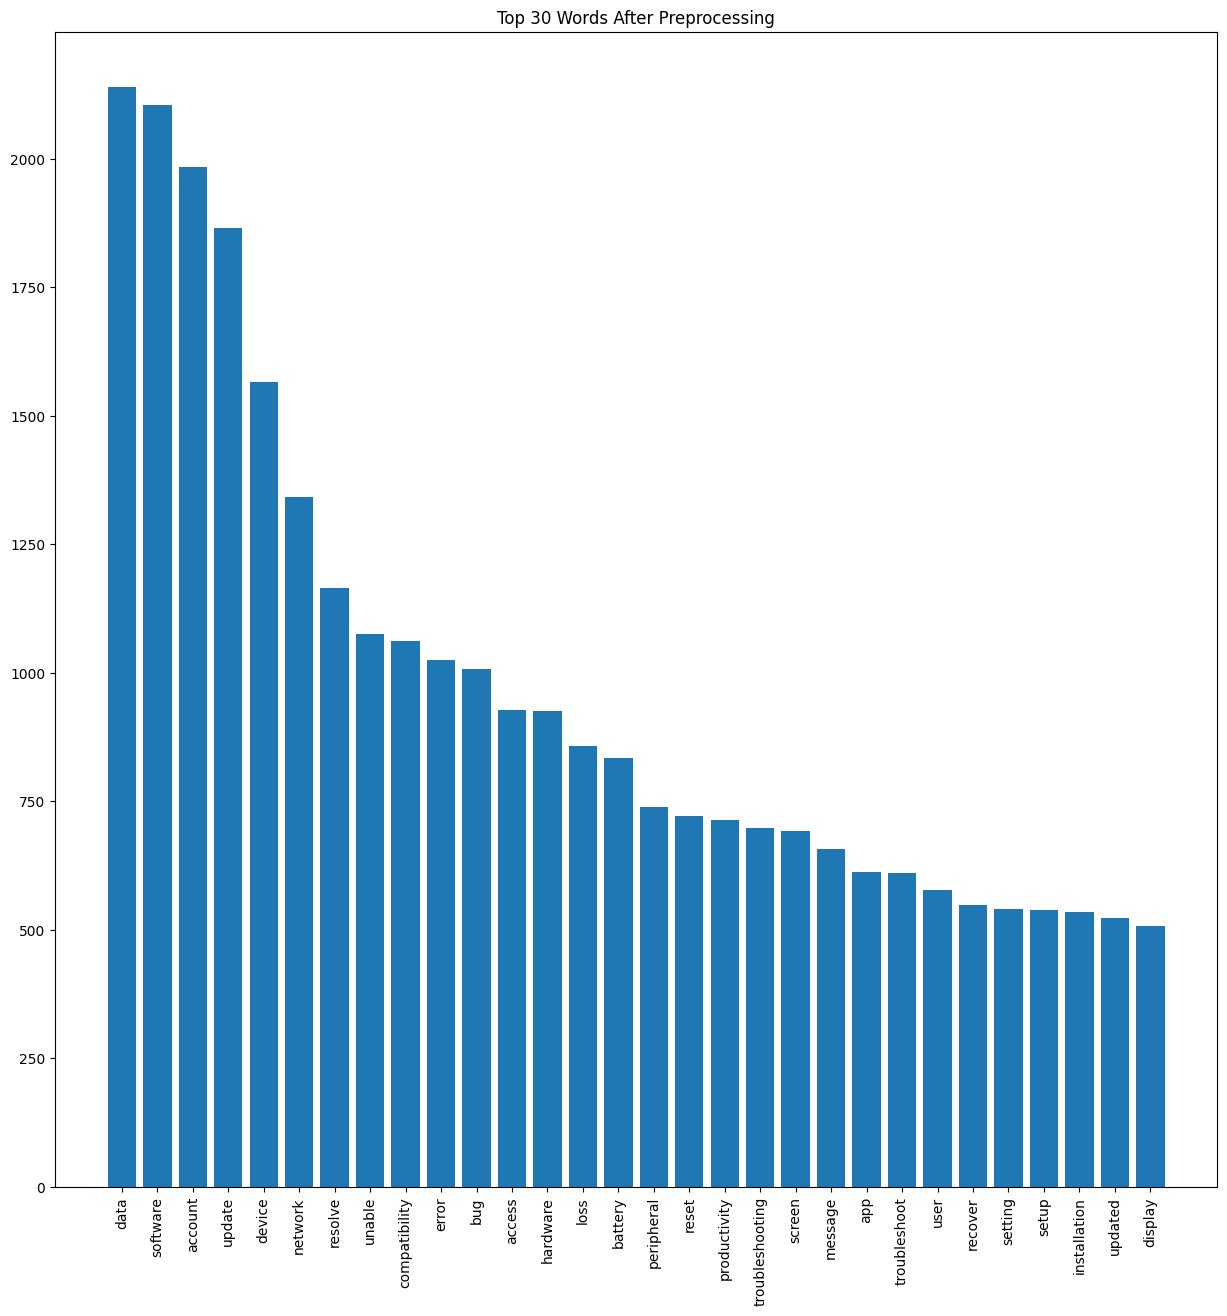

In [2461]:
text_data = data_df['processed_text'].astype(str)

all_words = " ".join(text_data).lower().split()
common_words = Counter(all_words).most_common(30)

words, counts = zip(*common_words)

plt.figure(figsize=(15, 15))
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Top 30 Words After Preprocessing")
plt.show()

### TFIDF

In [2462]:
tfidf = TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=5,max_df=0.7)

X = tfidf.fit_transform(data_df['processed_text'])

In [2463]:
X.shape

(8469, 1000)

In [2464]:
x_df = pd.DataFrame(X.toarray())
print(x_df.head())

   0    1        2    3    4    5    6    7    8    9    ...  990  991  \
0  0.0  0.0  0.00000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
1  0.0  0.0  0.00000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2  0.0  0.0  0.00000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
3  0.0  0.0  0.21717  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
4  0.0  0.0  0.00000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   

       992       993  994  995  996       997  998  999  
0  0.00000  0.000000  0.0  0.0  0.0  0.000000  0.0  0.0  
1  0.00000  0.000000  0.0  0.0  0.0  0.000000  0.0  0.0  
2  0.29979  0.300815  0.0  0.0  0.0  0.000000  0.0  0.0  
3  0.00000  0.000000  0.0  0.0  0.0  0.302294  0.0  0.0  
4  0.00000  0.000000  0.0  0.0  0.0  0.000000  0.0  0.0  

[5 rows x 1000 columns]


### Embeddings

In [2465]:
def clean_for_embeddings(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r"i'?m having an issue with.*?please assist\.?", ' ', text)
    text = re.sub(r'please assist\.?', ' ', text)
    text = re.sub(r'\b(id|created_at|product|price)\b', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [2466]:
data_df['embedding_text'] = data_df['text'].apply(clean_for_embeddings)

In [2467]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2468]:
embeddings = model.encode(data_df['embedding_text'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/265 [00:00<?, ?it/s]

In [2469]:
embeddings = normalize(embeddings)

In [2470]:
embeddings.shape

(8469, 384)

In [2471]:
embedding_df = pd.DataFrame(embeddings)
print(embedding_df.head())

        0         1         2         3         4         5         6    \
0  0.000270 -0.041218  0.036856 -0.020613 -0.026597 -0.030874 -0.059554   
1  0.010746 -0.124901  0.006918 -0.066395  0.033907 -0.040945 -0.064572   
2 -0.013071  0.092970  0.073024  0.016349 -0.004326 -0.022959 -0.039341   
3 -0.040583 -0.057087  0.007416  0.010493 -0.002672  0.023466 -0.015288   
4 -0.015533  0.112301  0.038948 -0.042822  0.033618  0.014868  0.000468   

        7         8         9    ...       374       375       376       377  \
0 -0.058937 -0.007972  0.036557  ...  0.008125 -0.019111 -0.034643 -0.032142   
1 -0.039987 -0.027893 -0.017844  ...  0.027218 -0.071396 -0.010199  0.007576   
2 -0.021063  0.043803 -0.033282  ... -0.011113 -0.047550 -0.023146  0.001471   
3 -0.072824  0.035632  0.026293  ... -0.002068 -0.010346  0.006322  0.001809   
4  0.059455  0.000845  0.122734  ...  0.038120 -0.012433  0.003243  0.054894   

        378       379       380       381       382       383  
0 -0

In [2472]:
cosine_similarity([embeddings[0]], [embeddings[1]])

array([[0.10283503]], dtype=float32)

In [2473]:
cosine_similarity([embeddings[2]], [embeddings[5]])

array([[0.60469484]], dtype=float32)

## Model

### Kmeans

#### TFIDF

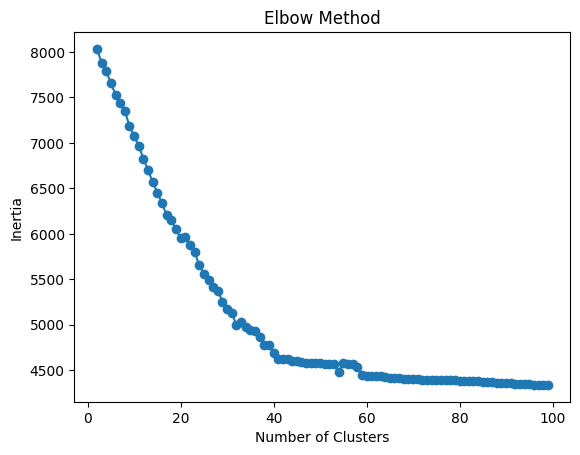

In [2474]:
inertia = []

for k in range(2, 100):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(range(2,100), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

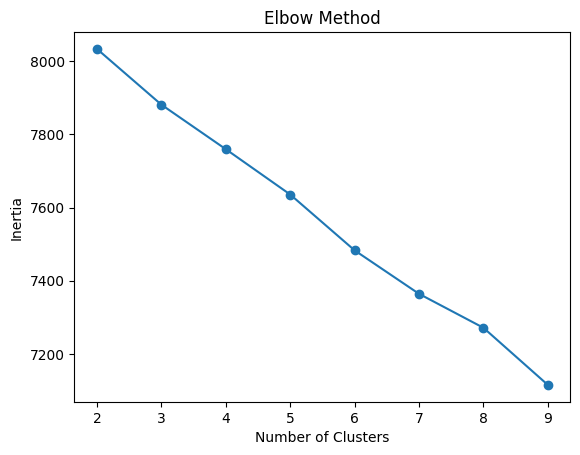

In [2475]:
inertia = []

for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [2476]:
k = 7

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
data_df['cluster'] = kmeans.fit_predict(X)

In [2477]:
terms = tfidf.get_feature_names_out()

def get_top_words_per_cluster(model, X, n=20):
    centroids = model.cluster_centers_
    
    for i in range(len(centroids)):
        top_indices = centroids[i].argsort()[-n:]
        top_words = [terms[j] for j in top_indices]
        
        print(f"\nCluster {i}:")
        print(top_words)

get_top_words_per_cluster(kmeans, X)


Cluster 0:
['network', 'update', 'troubleshooting', 'peripheral', 'manual', 'user manual', 'troubleshooting user', 'hardware', 'user', 'battery', 'compatibility', 'contacted unresolved', 'unresolved', 'contacted', 'unexpectedly', 'intermittent', 'intermittent unexpectedly', 'unable', 'software', 'productivity']

Cluster 1:
['experiencing', 'data loss', 'loss', 'app', 'update', 'software update', 'security', 'concerned', 'security data', 'concerned security', 'data safe', 'safe', 'havent', 'occurring', 'havent device', 'occurring software', 'update havent', 'software', 'device', 'data']

Cluster 2:
['network detect', 'device connecting', 'detect network', 'connecting done', 'done resolve', 'home wifi', 'trouble connecting', 'home', 'wifi', 'troubleshooting', 'network', 'website', 'website resolve', 'troubleshooting website', 'connecting', 'reset', 'factory', 'factory reset', 'reset resolve', 'resolve']

Cluster 3:
['battery', 'provide', 'account', 'network', 'installation', 'data loss'

| Cluster | Name                                           | Quality|
| ------- | ---------------------------------------------- | -------|
| 0       | Device, Hardware & Troubleshooting Issues      | Good   |
| 1       | Data Loss & Security Concerns                  | Good   |
| 2       | Network & WiFi Connectivity Issues             | Good   |
| 3       | System Errors & Firmware/Update Issues         | Good   |
| 4       | Software Bugs & UI Errors                      | Good   |
| 5       | Account Access & Password Recovery Issues      | Good   |
| 6       | User Troubleshooting & External Help Behaviour | Bad    |





In [2478]:
sil_scores = []

k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    sil_scores.append(score)

    print(f"k={k}, Silhouette Score={score:.4f}")

k=2, Silhouette Score=0.0186
k=3, Silhouette Score=0.0263
k=4, Silhouette Score=0.0318
k=5, Silhouette Score=0.0405
k=6, Silhouette Score=0.0494
k=7, Silhouette Score=0.0560
k=8, Silhouette Score=0.0625
k=9, Silhouette Score=0.0739


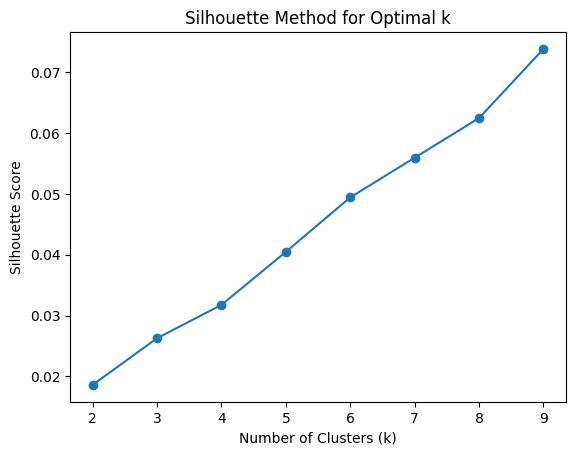

In [2479]:
plt.plot(k_values, sil_scores,  marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.show()

### Embeddings

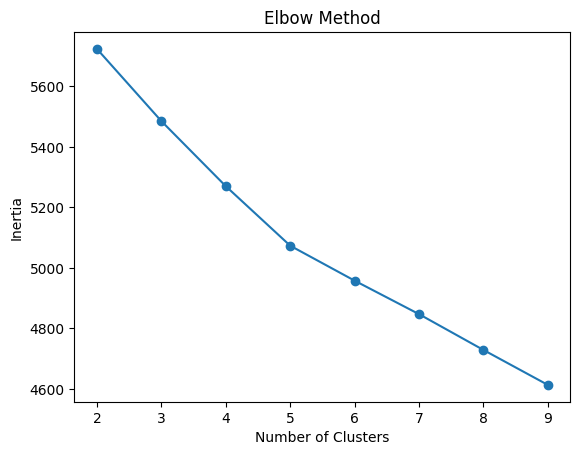

In [2480]:
inertia = []

for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(embeddings)
    inertia.append(model.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [2481]:
k = 7

kmeans_embed = KMeans(n_clusters=k, random_state=42, n_init=20)
data_df['cluster_embed'] = kmeans_embed.fit_predict(embeddings)

In [2482]:
for i in range(k):
    print(f"\nCluster {i}:")
    print(data_df[data_df['cluster_embed'] == i]['embedding_text'].head(5).tolist())


Cluster 0:
['data loss note the seller is not responsible for any damages arising out of the delivery of the battleground game please have the game in good condition and shipped to you i ve noticed a sudden decrease in battery life on my it used to last much longer', 'data loss search what s new in report feedback customer service is your best i m using the original charger that came with my but it s not charging properly', 'hardware issue we hope that every vendor takes the time it takes in to do the following remove the from your account notify consumers call them make their i m concerned about the security of my and would like to ensure that my data is safe', 'cancellation request thanks as a result all i m asking is to update i m concerned about the security of my and would like to ensure that my data is safe', 'display issue if you ve received a refund please contact customer service otherwise please call us at i m having an issue with the i m concerned about the security of my a

| Cluster | Name                                       | Quality   |
| ------- | ------------------------------------------ | --------- |
| 0       | Data Loss, Security & Battery Issues       | Ok  |
| 1       | Network Connectivity & Setup Issues        | Good      |
| 2       | Software Bugs & Firmware Update Issues     | Good      |
| 3       | Payment, Hardware & Intermittent Issues    | Ok  |
| 4       | Hardware Compatibility & Unresolved Issues | Good      |
| 5       | Battery Performance & Software Glitches    | Good      |
| 6       | Account Access & Authentication Issues     | Good |


### HAC

In [2483]:
X_dense = X.toarray()

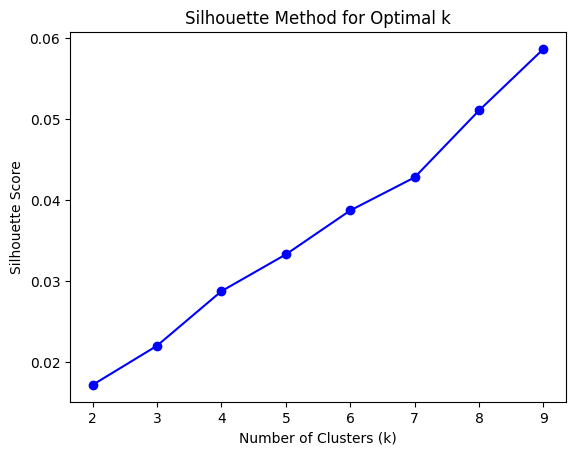

In [2484]:
scores = []
k_range = range(2, 10) # Silhouette requires at least 2 clusters

for k in k_range:
    hac = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hac.fit_predict(X_dense)
    score = silhouette_score(X_dense, labels)
    scores.append(score)

plt.plot(k_range, scores, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.show()

In [2485]:
hac_tfidf = AgglomerativeClustering(
    n_clusters=7,
    linkage='ward'
)

data_df['cluster_hac_tfidf'] = hac_tfidf.fit_predict(X_dense)

In [2486]:
for i in range(7):
    print(f"\nCluster {i}:")
    
    indices = np.where(data_df['cluster_hac_tfidf'] == i)[0]
    cluster_tfidf = X[indices].mean(axis=0)
    
    top_indices = np.argsort(cluster_tfidf.A1)[-20:][::-1]
    terms = tfidf.get_feature_names_out()
    
    print([terms[j] for j in top_indices])


Cluster 0:
['software', 'data', 'account', 'productivity', 'resolve', 'unable', 'device', 'compatibility', 'update', 'hardware', 'battery', 'bug', 'troubleshooting', 'network', 'software bug', 'reset', 'loss', 'data loss', 'intermittent', 'intermittent unexpectedly']

Cluster 1:
['afterward', 'afterward update', 'firmware afterward', 'updated firmware', 'firmware', 'updated', 'update', 'compatibility', 'installation', 'network', 'bug', 'software bug', 'display', 'battery', 'hardware', 'page', 'loss', 'setup', 'software', 'contact']

Cluster 2:
['update havent', 'occurring software', 'occurring', 'havent device', 'havent', 'software update', 'device', 'software', 'update', 'compatibility', 'hardware', 'setup', 'contact', 'installation', 'account', 'peripheral compatibility', 'bug', 'software bug', 'peripheral', 'account access']

Cluster 3:
['connecting', 'network', 'wifi', 'although device', 'connecting home', 'home wifi', 'network although', 'network detect', 'trouble connecting', 'd

| Cluster | Name                                   | Quality|
| ------- | -------------------------------------- | -------|
| 0       | General System & Mixed Issues          | Ok     |
| 1       | Firmware Updates & Installation Issues | Ok     |
| 2       | Software Update & Device Issues        | Ok     |
| 3       | Network & WiFi Connectivity Issues     | Good   |
| 4       | Error Messages & UI Issues             | Good   |
| 5       | Account Access & Credential Issues     | Good   |
| 6       | Data Security & Account Concerns       | Good   |


In [2487]:
hac_embed = AgglomerativeClustering(
    n_clusters=7,
    linkage='average'
)

data_df['cluster_hac_embed'] = hac_embed.fit_predict(embeddings)

In [2488]:
for i in range(7):
    print(f"\nCluster {i}:")
    
    cluster_indices = np.where(data_df['cluster_hac_embed'] == i)[0]
    cluster_embeddings = embeddings[cluster_indices]
    
    centroid = cluster_embeddings.mean(axis=0)
    distances = np.linalg.norm(cluster_embeddings - centroid, axis=1)
    
    closest = cluster_indices[np.argsort(distances)[:5]]
    
    for idx in closest:
        print("-", data_df['embedding_text'].iloc[idx])


Cluster 0:
- delivery problem i ll call you back at the earliest opportunity that i can preferably after i ve received the item in effect since march st of this year this problem started occurring after the recent software update i haven t made any other changes to the device
- setup otherwise we may make the payment via credit or debit we have no involvement in our products or services this problem started occurring after the recent software update i haven t made any other changes to the device
- payment issue you can download a replacement please i have an issue with the this problem started occurring after the recent software update i haven t made any other changes to the device
- setup you are making a purchase to help others who need help paying a purchase we re only able to work with you if we give a certain number and if you i ve recently updated the firmware of my and the issue started happening afterward could it be related to the update
- payment issue you can always email m

| Cluster | Name                                      | Quality|
| ------- | ----------------------------------------- | -------|
| 0       | Mixed Issues (Delivery, Payment, Updates) | Bad    |
| 1       | Setup & Configuration Issues              | Ok     |
| 2       | Performance & User Behaviour Issues       | Ok     |
| 3       | Weak / Undefined Cluster                  | Bad    |
| 4       | Data Security Concerns                    | Ok     |
| 5       | Performance & Battery Issues              | Ok     |
| 6       | Support, Updates & Unresolved Issues      | Ok     |


In [2490]:
lda = LatentDirichletAllocation(n_components=7,random_state=42,learning_method='batch')

lda.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",7
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [2491]:
def display_topics(model, feature_names, n_top_words=10):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topics.append((topic_idx, top_words))
    return topics

feature_names = tfidf.get_feature_names_out()
topics = display_topics(lda, feature_names)

for idx, words in topics:
    print(f"Topic {idx}: {words}")

Topic 0: ['update', 'software', 'software update', 'updated', 'havent', 'afterward', 'afterward update', 'firmware', 'updated firmware', 'firmware afterward']
Topic 1: ['data', 'connecting', 'device', 'correctly', 'lost', 'hindering', 'hindering productivity', 'configured', 'rely hindering', 'rely']
Topic 2: ['message', 'error message', 'peculiar', 'popping screen', 'popping', 'message popping', 'peculiar error', 'error', 'screen', 'battery']
Topic 3: ['intermittent', 'intermittent unexpectedly', 'unexpectedly', 'access', 'account', 'charging', 'came', 'charger', 'came charging', 'charger came']
Topic 4: ['hardware', 'website', 'configuration', 'website resolve', 'setting configuration', 'troubleshooting website', 'experiencing', 'model', 'account', 'device model']
Topic 5: ['reset', 'resolve', 'factory', 'factory reset', 'reset resolve', 'data', 'safe', 'data safe', 'security', 'concerned']
Topic 6: ['contacted', 'contacted unresolved', 'unresolved', 'user', 'manual', 'troubleshooting

| Method              | Strength        | Weakness           |
| ------------------- | --------------- | ------------------ |
| TF-IDF + KMeans     | Clean clusters  | less semantic      |
| TF-IDF + HAC        | hierarchical    | mixed clusters     |
| Embeddings + KMeans | semantic        | less interpretable |
| Embeddings + HAC    | weak            | noisy              |
| **LDA (TF-IDF)**    | topic discovery | mixed topics       |
